In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram

%matplotlib inline

In [3]:
df = pd.read_csv('/content/Wine_clust.csv')

In [4]:
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [5]:
df.shape

(178, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [7]:
df.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [8]:
df.isnull().sum()

,0
Alcohol,0
Malic_Acid,0
Ash,0
Ash_Alcanity,0
Magnesium,0
Total_Phenols,0
Flavanoids,0
Nonflavanoid_Phenols,0
Proanthocyanins,0
Color_Intensity,0


In [9]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

scaled_df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


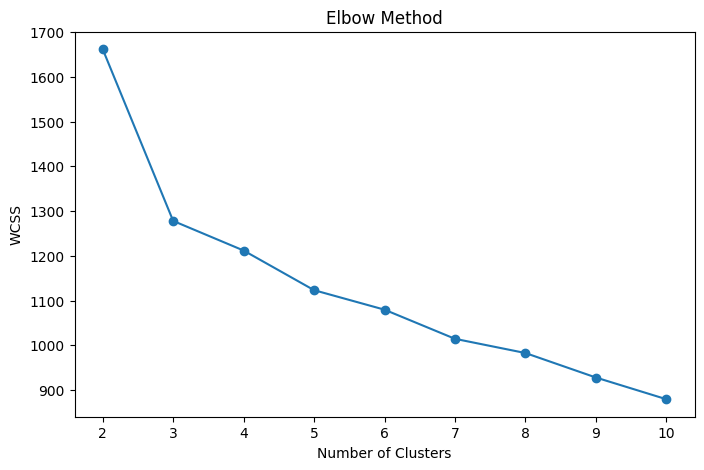

In [10]:
wcss = []

for i in range(2,11):
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(scaled_df)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

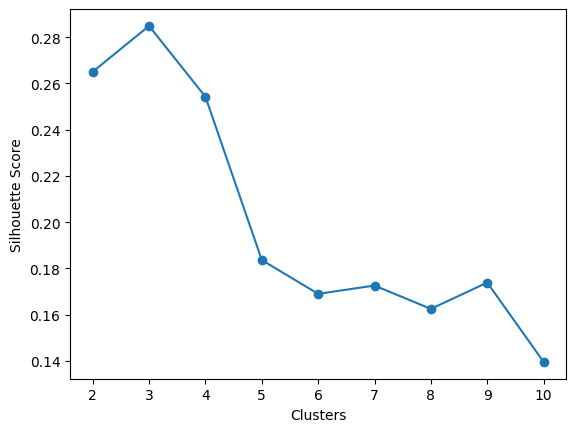

[np.float64(0.2650328591008738),
 np.float64(0.2848589191898987),
 np.float64(0.25422758316007776),
 np.float64(0.18362105107698137),
 np.float64(0.16899191019013057),
 np.float64(0.1726015561094921),
 np.float64(0.16250411307671142),
 np.float64(0.1738739334545086),
 np.float64(0.13956723664297546)]

In [11]:
scores = []

for i in range(2,11):
    model = KMeans(n_clusters=i, random_state=42)
    labels = model.fit_predict(scaled_df)
    scores.append(silhouette_score(scaled_df, labels))

plt.plot(range(2,11), scores, marker='o')
plt.xlabel("Clusters")
plt.ylabel("Silhouette Score")
plt.show()

scores

In [12]:
kmeans = KMeans(n_clusters=3, random_state=42)

kmeans_labels = kmeans.fit_predict(scaled_df)

df["KMeans"] = kmeans_labels

df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,KMeans
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2


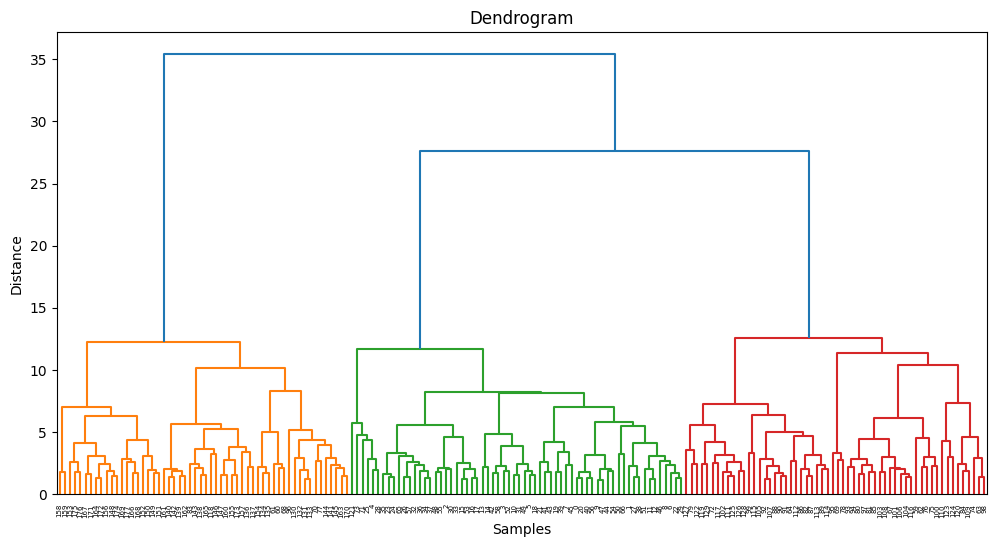

In [13]:
plt.figure(figsize=(12,6))

dendrogram(linkage(scaled_df, method='ward'))

plt.title("Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")

plt.show()

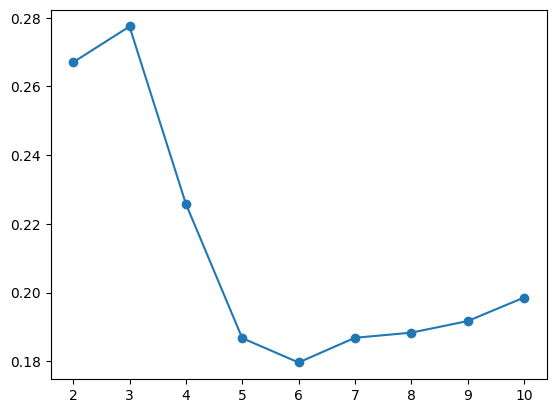

[np.float64(0.2670131771272231),
 np.float64(0.2774439826952265),
 np.float64(0.225836659334758),
 np.float64(0.18674235566758707),
 np.float64(0.17966642854438503),
 np.float64(0.18685342560226942),
 np.float64(0.18834697102837825),
 np.float64(0.1917169293227209),
 np.float64(0.19856750165505588)]

In [14]:
scores = []

for i in range(2,11):
    model = AgglomerativeClustering(n_clusters=i)
    labels = model.fit_predict(scaled_df)
    scores.append(silhouette_score(scaled_df, labels))

plt.plot(range(2,11), scores, marker='o')
plt.show()

scores

In [15]:
hc = AgglomerativeClustering(n_clusters=3)

hc_labels = hc.fit_predict(scaled_df)

df["Hierarchical"] = hc_labels

df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,KMeans,Hierarchical
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2,2
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2,2
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2,2
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2,2
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2,2


In [16]:
dbscan = DBSCAN(eps=2, min_samples=5)

db_labels = dbscan.fit_predict(scaled_df)

df["DBSCAN"] = db_labels

df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,KMeans,Hierarchical,DBSCAN
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2,2,0
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2,2,0
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2,2,0
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2,2,0
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2,2,-1


In [17]:
df["DBSCAN"].value_counts()

,count
DBSCAN,
-1,85
0,66
4,9
1,8
2,5
3,5


In [18]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_df)

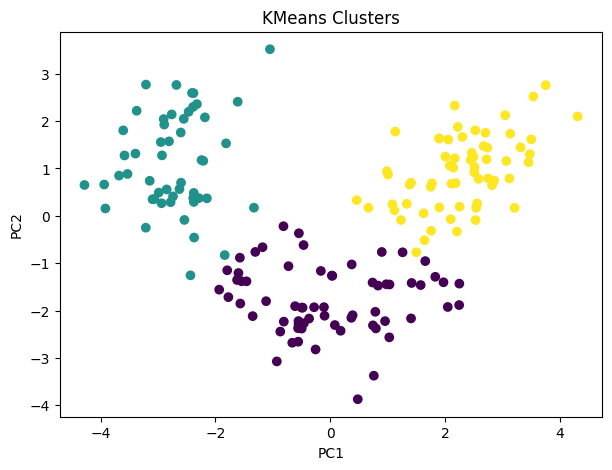

In [19]:
plt.figure(figsize=(7,5))
plt.scatter(pca_data[:,0], pca_data[:,1], c=kmeans_labels)
plt.title("KMeans Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

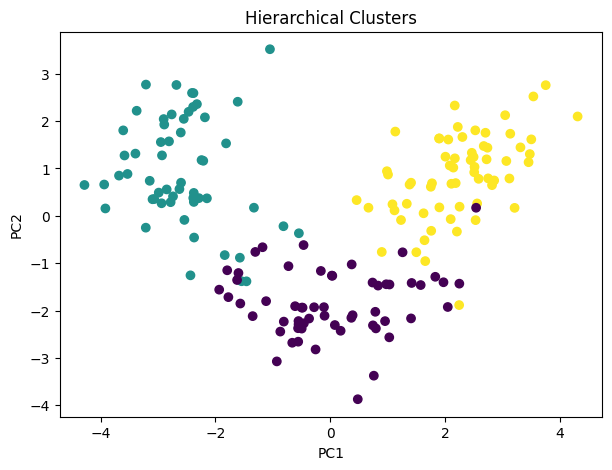

In [20]:
plt.figure(figsize=(7,5))
plt.scatter(pca_data[:,0], pca_data[:,1], c=hc_labels)
plt.title("Hierarchical Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

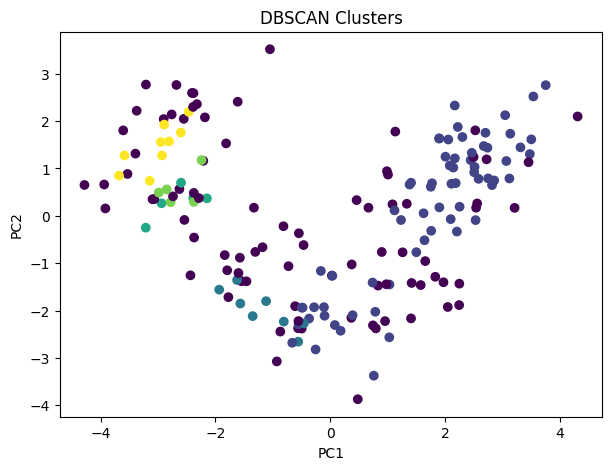

In [21]:
plt.figure(figsize=(7,5))
plt.scatter(pca_data[:,0], pca_data[:,1], c=db_labels)
plt.title("DBSCAN Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [22]:
comparison = pd.DataFrame({
    "Model": ["KMeans", "Hierarchical", "DBSCAN"],
    "Silhouette Score": [
        silhouette_score(scaled_df, kmeans_labels),
        silhouette_score(scaled_df, hc_labels),
        silhouette_score(scaled_df, db_labels) if len(set(db_labels)) > 1 else np.nan
    ]
})

comparison

,Model,Silhouette Score
0,KMeans,0.284859
1,Hierarchical,0.277444
2,DBSCAN,-0.032906
